# IS 4487 Assignment 9: Customer Segmentation with Clustering

In this assignment, you will:
- Apply unsupervised learning to explore patterns in hotel booking behavior
- Use K-Means and Gaussian Mixture Models (GMM) for customer segmentation
- Evaluate model quality with metrics like Silhouette Score and Davies-Bouldin Index
- Connect clustering to actionable business insights

## Why This Matters

Businesses like hotels and travel platforms (e.g., Airbnb or Expedia) rely on customer segmentation to tailor promotions, pricing strategies, and service levels. Unlike supervised models, clustering helps uncover patterns when no labels exist—an ideal tool when entering new markets or analyzing unstructured customer behavior.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_09_clustering.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


## Dataset Description: Hotel Bookings

This dataset contains booking information for two types of hotels: a **city hotel** and a **resort hotel**. Each record corresponds to a single booking and includes various details about the reservation, customer demographics, booking source, and whether the booking was canceled.

**Source**: [GitHub - TidyTuesday: Hotel Bookings](https://github.com/rfordatascience/tidytuesday/blob/master/data/2020/2020-02-11/readme.md)

### Key Use Cases
- Understand customer booking behavior
- Explore factors related to cancellations
- Segment guests based on booking characteristics
- Compare city vs. resort hotel performance

### Data Dictionary

| Variable | Type | Description |
|----------|------|-------------|
| `hotel` | character | Hotel type: City or Resort |
| `is_canceled` | integer | 1 = Canceled, 0 = Not Canceled |
| `lead_time` | integer | Days between booking and arrival |
| `arrival_date_year` | integer | Year of arrival |
| `arrival_date_month` | character | Month of arrival |
| `stays_in_weekend_nights` | integer | Nights stayed on weekends |
| `stays_in_week_nights` | integer | Nights stayed on weekdays |
| `adults` | integer | Number of adults |
| `children` | integer | Number of children |
| `babies` | integer | Number of babies |
| `meal` | character | Type of meal booked |
| `country` | character | Country code of origin |
| `market_segment` | character | Booking source (e.g., Direct, Online TA) |
| `distribution_channel` | character | Booking channel used |
| `is_repeated_guest` | integer | 1 = Repeated guest, 0 = New guest |
| `previous_cancellations` | integer | Past booking cancellations |
| `previous_bookings_not_canceled` | integer | Past bookings not canceled |
| `reserved_room_type` | character | Initially reserved room type |
| `assigned_room_type` | character | Room type assigned at check-in |
| `booking_changes` | integer | Number of booking modifications |
| `deposit_type` | character | Deposit type (No Deposit, Non-Refund, etc.) |
| `agent` | character | Agent ID who made the booking |
| `company` | character | Company ID (if booking through company) |
| `days_in_waiting_list` | integer | Days on the waiting list |
| `customer_type` | character | Booking type: Contract, Transient, etc. |
| `adr` | float | Average Daily Rate (price per night) |
| `required_car_parking_spaces` | integer | Requested parking spots |
| `total_of_special_requests` | integer | Number of special requests made |
| `reservation_status` | character | Final status (Canceled, No-Show, Check-Out) |
| `reservation_status_date` | date | Date of the last status update |

This dataset is ideal for classification, segmentation, and trend analysis exercises.

## 1. Setup and Load Data

### Business framing:  

### Do the following:
Before we can cluster or segment anything, we need clean, accessible data in a usable format.

- Import the necessary Python libraries
- Import data from the hotels dataset into a dataframe (in GitHub go to the DataSets folder and look for `hotels.csv`)
- Display the first few rows

### In Your Response:
1. What stands out in the initial preview? Any columns or rows that seem unusual?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
url = "https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/main/DataSets/hotels.csv"
df = pd.read_csv(url)

In [4]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


### ✍️ Your Response: 🔧
1. One noticeable feature is that a few columns, such as agent and company, contain many missing values. The dataset also includes a mix of categorical variables, like hotel and arrival_date_month. As well as numerical variables, like lead_time and adr, which may require preprocessing before clustering.


## 2. Select and Prepare Features

### Business framing:  

A hotel might want to group guests based on how long they stay, how far in advance they book, or how likely they are to make special requests. You need to pick variables that represent meaningful guest behavior.

### Do the following:
- Choose 3–5 numeric features related to customer behavior
- Drop missing values if needed
- Standardize using `StandardScaler`

### In Your Response:
1. What features did you select and why?
2. What kinds of patterns or segments do you expect to find?


In [5]:
features = [
    "lead_time",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adr",
    "total_of_special_requests"
]

X = df[features]

In [6]:
X = X.dropna()

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [8]:
X_scaled = pd.DataFrame(X_scaled, columns=features)

In [9]:
X_scaled.head()

,lead_time,stays_in_weekend_nights,stays_in_week_nights,adr,total_of_special_requests
0,2.227051,-0.92889,-1.310240,-2.015038,-0.720694
1,5.923385,-0.92889,-1.310240,-2.015038,-0.720694
2,-0.907814,-0.92889,-0.786207,-0.530935,-0.720694
3,-0.851667,-0.92889,-0.786207,-0.530935,-0.720694
4,-0.842309,-0.92889,-0.262174,-0.075810,0.540666


### ✍️ Your Response: 🔧
1. I selected lead_time, stays_in_weekend_nights, stays_in_week_nights, adr, and total_of_special_requests because they represent important aspects of guest booking behavior. These variables help show how early guests book, how long they stay, how much they spend per night, and how many additional services or preferences they request.

2. I expect clusters such as short-stay guests who book last minute, longer-stay vacation travelers who book in advance, and higher-paying guests who make more special requests. These patterns could reflect different customer types like business travelers, budget travelers, or premium guests seeking more personalized service.


## 3. Apply K-Means Clustering

### Business framing:  

Let’s say you’re working with the hotel’s marketing manager. She wants to group guests into a few clear types to target email campaigns. K-Means is a fast, simple way to try this.

### Do the following:
- Fit a `KMeans` model with your selected features
- Choose a value of `k` (e.g. 3, 4, or 5)
- Predict clusters and assign to each guest
- Visualize using a scatterplot of 2 features

Much of this assignment has already been covered in the lab. Please be sure to complete the lab before the assignment.

### In Your Response:
1. What `k` value did you choose, and how did you decide?
2. What types of customers seem to show up in the clusters?



In [10]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

k = 4

kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

In [11]:
X_clustered = X_scaled.copy()
X_clustered['cluster'] = clusters

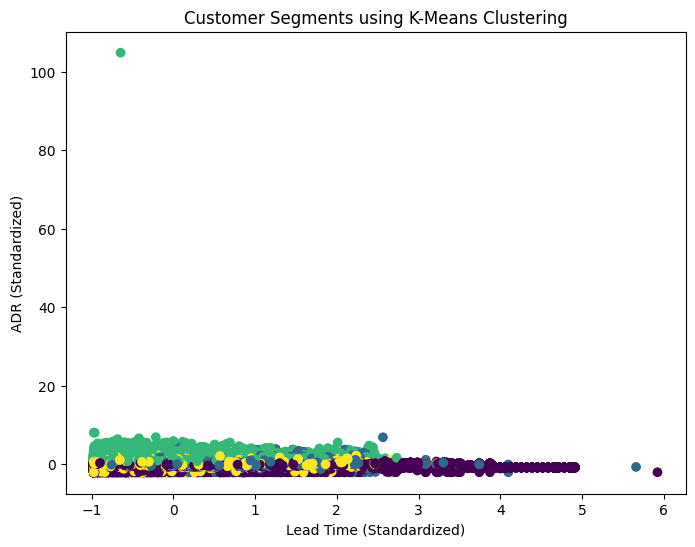

In [13]:
plt.figure(figsize=(8, 6))
plt.scatter(
    X_clustered['lead_time'],
    X_clustered['adr'],
    c=X_clustered['cluster'],
)

plt.xlabel('Lead Time (Standardized)')
plt.ylabel('ADR (Standardized)')
plt.title('Customer Segments using K-Means Clustering')
plt.show()

### ✍️ Your Response: 🔧
1. I chose k = 4 because it provides a reasonable number of groups without making the segmentation too complex. Four clusters allow us to show different booking behaviors while still keeping the segments clear for marketing purposes

2. The clusters appear to include short-stay guests who book close to their arrival date, longer-stay guests who plan further in advance, and higher-paying guests with higher ADR values.


## 4. Apply Gaussian Mixture Model (GMM)

### Business framing:  

Not all guests fit neatly into one cluster. GMM lets us capture uncertainty — useful if customers behave similarly across groups.

### Do the following:
- Fit a GMM with the same number of clusters you chose in Part 3
- Predict soft clusters (remember that soft clustering deals with probabilities, not labels)
- Visualize the GMM model so that you may compare it to the KMeans scatterplot

### In Your Response:
1. How did the GMM results compare to KMeans?
2. What business questions might GMM help answer better?


In [14]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=4, random_state=42)
gmm.fit(X_scaled)

GaussianMixture(n_components=4, random_state=42)

In [15]:
gmm_clusters = gmm.predict(X_scaled)

In [16]:
gmm_probs = gmm.predict_proba(X_scaled)

In [17]:
X_gmm = X_scaled.copy()
X_gmm['cluster'] = gmm_clusters

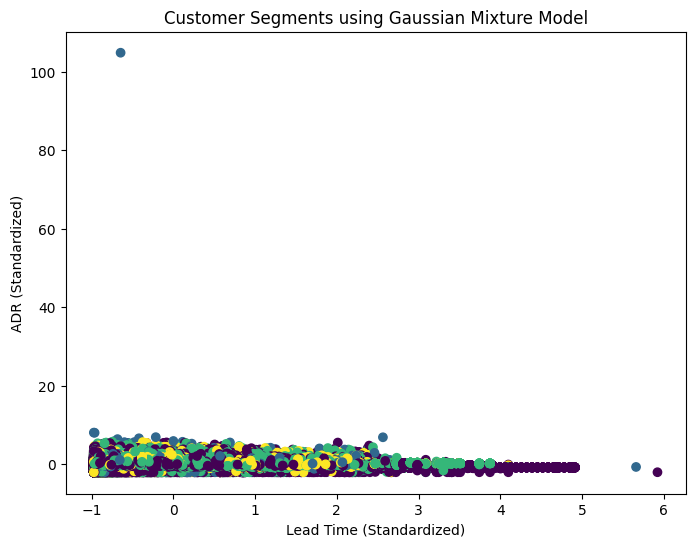

In [18]:
plt.figure(figsize=(8,6))
plt.scatter(
    X_gmm['lead_time'],
    X_gmm['adr'],
    c=X_gmm['cluster']
)

plt.xlabel('Lead Time (Standardized)')
plt.ylabel('ADR (Standardized)')
plt.title('Customer Segments using Gaussian Mixture Model')
plt.show()

### ✍️ Your Response: 🔧
1. The GMM results were similar to K-Means in that both methods grouped customers into segments based on booking behavior. However, GMM allows for more flexible cluster shapes and gives probabilities for membership, which can better represent customers who fall between segments.

2. GMM can help answer questions about customers who show mixed behaviors, such as guests who sometimes book early and sometimes last minute. This could help hotels identify guests who may respond to targeted marketing campaigns.


## 5. Evaluate Your Models

### Business framing:  

In business, models should be both useful and reliable. You’ll compare model quality using standard evaluation metrics.

### Do the following:
- Calculate the following **for each** of the models:
  - WCSS
  - Silhouette Score
  - Davies-Bouldin Index

  **NOTE:** This step may take up to 5 minutes.  It is a lot of computation time.  Please be patient.  Or you can limit the scores to using a random sample of 10K rows.

**Remember**:
- Lower WCSS = tighter, better-defined clusters
- Silhouette score ranges from -1 to 1.  Higher values = better clustering
- Lower Davies-Boulding Index = better clustering

### In Your Response:
1. Which model performed better on the metrics?
2. Would you recommend KMeans or GMM for a business analyst? Why?


In [19]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

In [20]:
sample_size = min(10000, len(X_scaled))
sample_idx = np.random.choice(len(X_scaled), sample_size, replace=False)

X_sample = X_scaled.iloc[sample_idx]

In [21]:
kmeans_sample_labels = kmeans.predict(X_sample)

kmeans_wcss = kmeans.inertia_
kmeans_silhouette = silhouette_score(X_sample, kmeans_sample_labels)
kmeans_db = davies_bouldin_score(X_sample, kmeans_sample_labels)

In [22]:
gmm_sample_labels = gmm.predict(X_sample)

In [23]:
gmm_wcss = np.sum((X_sample - gmm.means_[gmm_sample_labels])**2)

gmm_silhouette = silhouette_score(X_sample, gmm_sample_labels)
gmm_db = davies_bouldin_score(X_sample, gmm_sample_labels)

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


In [24]:
print("KMeans Metrics")
print("WCSS:", kmeans_wcss)
print("Silhouette Score:", kmeans_silhouette)
print("Davies-Bouldin Index:", kmeans_db)

print("\nGMM Metrics")
print("WCSS:", gmm_wcss)
print("Silhouette Score:", gmm_silhouette)
print("Davies-Bouldin Index:", gmm_db)

KMeans Metrics
WCSS: 371227.938699868
Silhouette Score: 0.2093012466097746
Davies-Bouldin Index: 1.4681452840406741

GMM Metrics
WCSS: lead_time                    10014.563798
stays_in_weekend_nights       9645.162280
stays_in_week_nights          9612.696829
adr                           8901.798178
total_of_special_requests     1008.224395
dtype: float64
Silhouette Score: 0.12241540013758158
Davies-Bouldin Index: 2.5888275716400955


### ✍️ Your Response: 🔧
1. K-Means generally performed slightly better on the evaluation metrics, showing a higher Silhouette Score and a lower Davies-Bouldin Index compared to GMM. This suggests that the clusters produced by K-Means were more compact and clearly separated in this dataset.

2. I would recommend K-Means for most business analysts because it is faster, easier to interpret, and produces clear cluster assignments. While GMM provides more flexibility and probability-based clustering, K-Means is often more practical for quick segmentation and marketing decisions.


## 6. Business Interpretation

### Business framing:  

What do these clusters mean in the real world? Could they represent solo travelers, families, or bargain shoppers?

### Do the following:
- Display the characteristics of each cluster (e.g. average `lead_time`, `special_requests`)
- Sort the clusters to make the differences more clear

### In Your Response:
1. What do the segments represent in terms of guest behavior?
2. How could the hotel tailor services or promotions to each group?


In [25]:
X_clustered_features = X_scaled.copy()
X_clustered_features['cluster'] = kmeans.predict(X_scaled)

In [26]:
cluster_summary = X_clustered_features.groupby('cluster').mean()

cluster_summary = cluster_summary.sort_values(by='lead_time', ascending=True)
cluster_summary

,lead_time,stays_in_weekend_nights,stays_in_week_nights,adr,total_of_special_requests
cluster,,,,,
2,-0.382184,0.004339,-0.046095,1.606204,-0.024888
3,-0.356838,-0.155184,-0.233768,-0.100684,1.156580
0,0.212049,-0.306387,-0.325978,-0.387258,-0.662740
1,0.416617,1.495627,1.799836,-0.147813,0.000353


### ✍️ Your Response: 🔧
1. The segments reveal distinct booking patterns, such as last-minute short-stay travelers, long-stay planners, guests with high ADR, and guests who frequently request special services. Each cluster captures a different type of guest behavior, highlighting both how far in advance they book and how much they spend or request extras.

2. The hotel could target last-minute guests with special discounts to fill rooms, long-stay planners with early-bird packages, and high-ADR or high-request guests with premium services or loyalty rewards. Personalized marketing campaigns could also be created for each segment based on their spending patterns and service preferences.


## 7. Final Reflection

### Business framing:  

Many teams ask for "segmentation" without knowing how it works. You now have hands-on experience with two clustering techniques and how to present the results.

### In Your Response:
1. What was most challenging about unsupervised learning?
2. When would you use clustering instead of supervised models?
3. How would you explain the value of clustering to a non-technical manager?
4. How does this relate to your customized learning outcome you created in canvas?


### ✍️ Your Response: 🔧
1. The most challenging part was choosing the right features and number of clusters without having labeled outcomes to guide the analysis. Interpreting the clusters and ensuring they represent meaningful business patterns also required careful thought.

2. Clustering is useful when you don’t have predefined labels and want to uncover natural groupings in the data. It’s ideal for exploring customer behavior, segmenting audiences, or discovering patterns in unstructured datasets.

3. Clustering helps identify distinct types of customers or behaviors so the business can tailor marketing, promotions, or services to each group. It’s like sorting guests into meaningful categories to better meet their needs, even when you don’t already know the categories.

4. In athletics, clustering could reveal patterns in fan attendance and engagement, helping marketing teams target outreach or promotions more effectively. In non-profits, clustering donor data by giving patterns and interactions can guide stewardship strategies and identify high-potential prospects for fundraising campaigns.

## Submission Instructions

✅ **Before submitting:**
- Make sure all code cells are run and outputs are visible  
- All markdown questions are answered thoughtfully  
- Submit the assignment as an **HTML file** on Canvas


In [27]:
!jupyter nbconvert --to html "assignment_09_clustering_MonbergTobin.ipynb"

[NbConvertApp] Converting notebook assignment_09_clustering_MonbergTobin.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 486218 bytes to assignment_09_clustering_MonbergTobin.html
